[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juansensio/blog/blob/master/096_ml_unsupervised/096_ml_unsupervised.ipynb)

## Clustering

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATASETS/playdataset4.csv')

In [ ]:
import matplotlib.pyplot as plt

def plot_clusters(data, y=None, xlim=None, ylim=None):
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=y, s=1)
    plt.xlabel(data.columns[0], fontsize=14)
    plt.ylabel(data.columns[1], fontsize=14, rotation=0)
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

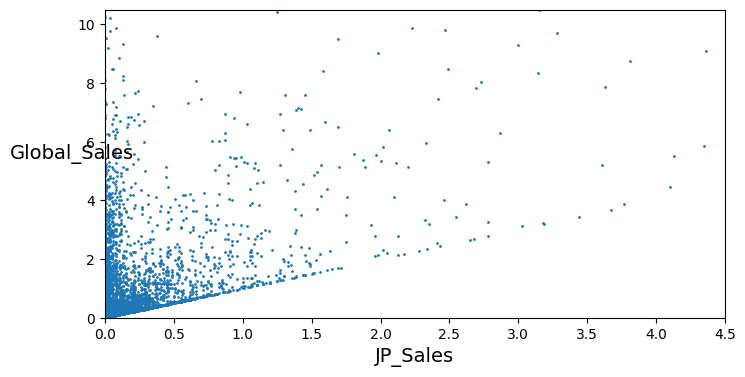

In [ ]:
plt.figure(figsize=(8, 4))
plot_clusters(data, xlim=(0, 4.5), ylim=(0, 10.5))
plt.show()

In [ ]:
from sklearn.cluster import KMeans
k = 9
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(data.values)
y_pred

array([2, 4, 4, ..., 0, 0, 0], dtype=int32)

In [ ]:
kmeans.cluster_centers_

array([[3.62517710e-02, 2.01392746e-01],
       [1.40585714e+00, 1.03462857e+01],
       [3.77000000e+00, 8.27400000e+01],
       [5.46633663e-01, 4.29128713e+00],
       [4.74777778e+00, 3.18500000e+01],
       [3.31388889e+00, 1.96466667e+01],
       [1.78732323e-01, 1.46294444e+00]])

In [ ]:
import numpy as np

data_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(data_new)

array([6, 6, 6, 6], dtype=int32)

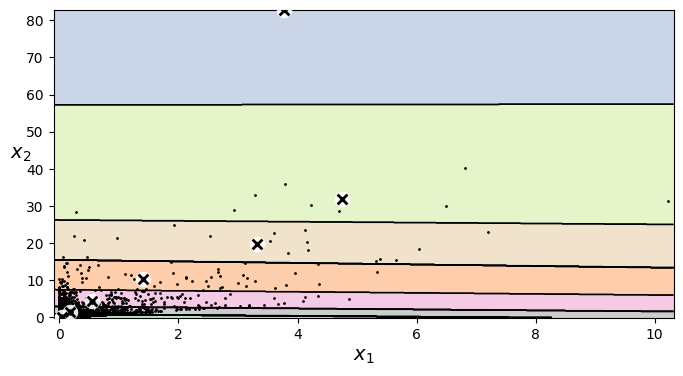

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# Definiciones de funciones de graficación
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

# Código original de la celda para graficar
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, data.values)
plt.show()

In [ ]:
kmeans.transform(data_new)

array([[ 1.79897255,  8.46385961, 80.82796855,  2.35559017, 30.2252195 ,
        17.9551303 ,  0.56601582],
       [ 3.46681289,  8.49716286, 80.74367158,  3.35693358, 29.90112418,
        17.64945808,  2.87192966],
       [ 4.12928897,  8.56618299, 80.02687361,  3.77439171, 29.87223729,
        17.80383959,  3.53084678],
       [ 3.80820432,  8.99865416, 80.52509236,  3.97332605, 30.35540414,
        18.27220213,  3.34362429]])

In [ ]:
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="full", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="lloyd", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=5,
                    #  algorithm="elkan", max_iter=1, random_state=1)
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=2, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter2 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=3, random_state=1)
# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter3 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(data.values)
kmeans_iter2.fit(data.values)
kmeans_iter3.fit(data.values)

KMeans(algorithm='elkan', max_iter=3, n_clusters=5, n_init=1, random_state=5)

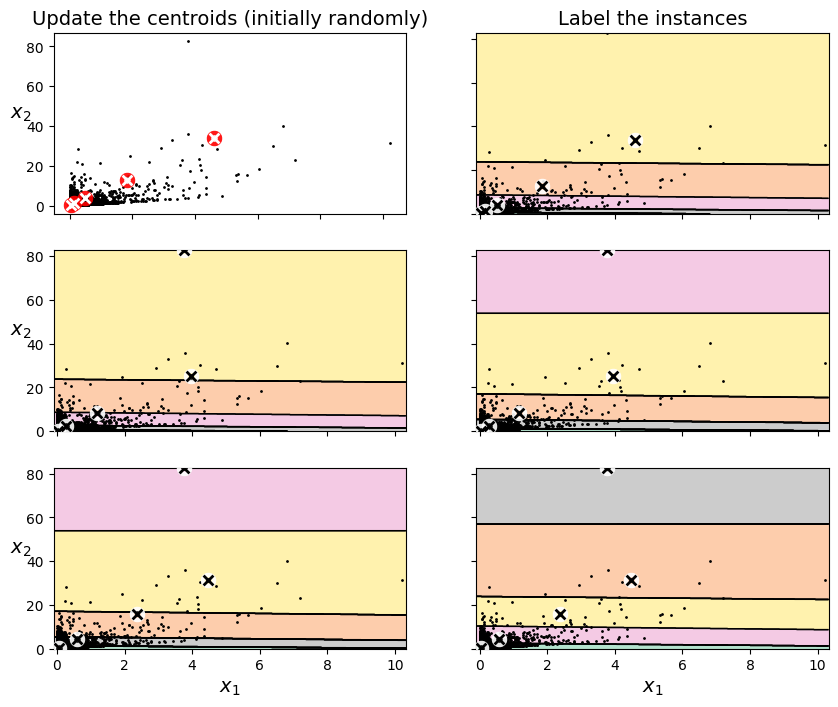

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(data.values)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, data.values, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, data.values, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, data.values, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, data.values, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, data.values, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [ ]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

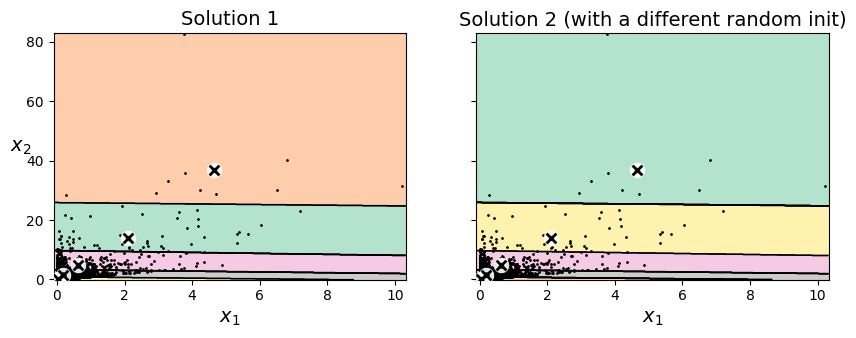

In [ ]:
kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, data.values,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para minimizar el impacto de la inicialización tenemos varias alternativas: probar varias y quedarnos con la mejor, o usar la inicialización inteligente que ofrece *Scikit-Learn* por defecto.

In [ ]:
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(data.values)

KMeans(algorithm='elkan', init='random', n_clusters=5, n_init=10,
       random_state=11)

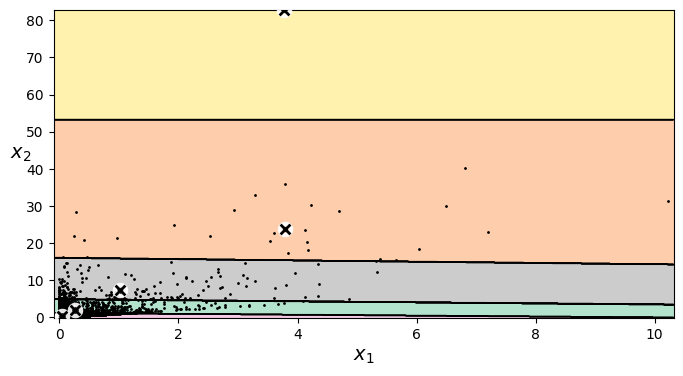

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, data.values)
plt.show()

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
mnist.target = mnist.target.astype(np.int64)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    mnist["data"], mnist["target"], random_state=42)

In [ ]:
def load_next_batch(batch_size): # se escoge al azar un tamaño de reemplazo
    return X_train.iloc[np.random.choice(len(X_train), batch_size, replace=False)]

In [ ]:
from sklearn.cluster import MiniBatchKMeans
#con ayuda de chat
k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [ ]:
best_kmeans.score(X_train)

-149972299279.7677

### Encontrando el número óptimo de grupos

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

# Definir un rango de k a evaluar (por ejemplo, de 2 a 10)
ks_to_evaluate = range(2, 11)

# Entrenar modelos KMeans para cada k y calcular los silhouette scores
silhouette_scores = []
kmeans_per_k = []
for k in ks_to_evaluate:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data.values)
    kmeans_per_k.append(kmeans)
    score = silhouette_score(data.values, kmeans.labels_)
    silhouette_scores.append(score)

# Encontrar el índice del mejor score
best_k_index = np.argmax(silhouette_scores)

# Obtener el mejor k y su score
best_k = ks_to_evaluate[best_k_index]
best_score = silhouette_scores[best_k_index]

print(f"El número óptimo de clusters (basado en silhouette score) es: {best_k} con un silhouette score de: {best_score:.4f}")

# Puedes acceder al mejor modelo KMeans con kmeans_per_k[best_k_index]
best_kmeans_model = kmeans_per_k[best_k_index]

El número óptimo de clusters (basado en silhouette score) es: 2 con un silhouette score de: 0.9522


Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

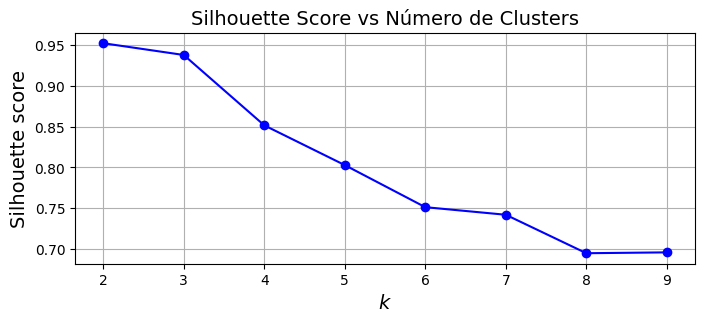

In [ ]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(data.values) for k in range(2, 10)]
silhouette_scores = [silhouette_score(data.values, model.labels_) for model in kmeans_per_k]

ks = list(range(2, 10))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

<Figure size 1100x900 with 0 Axes>

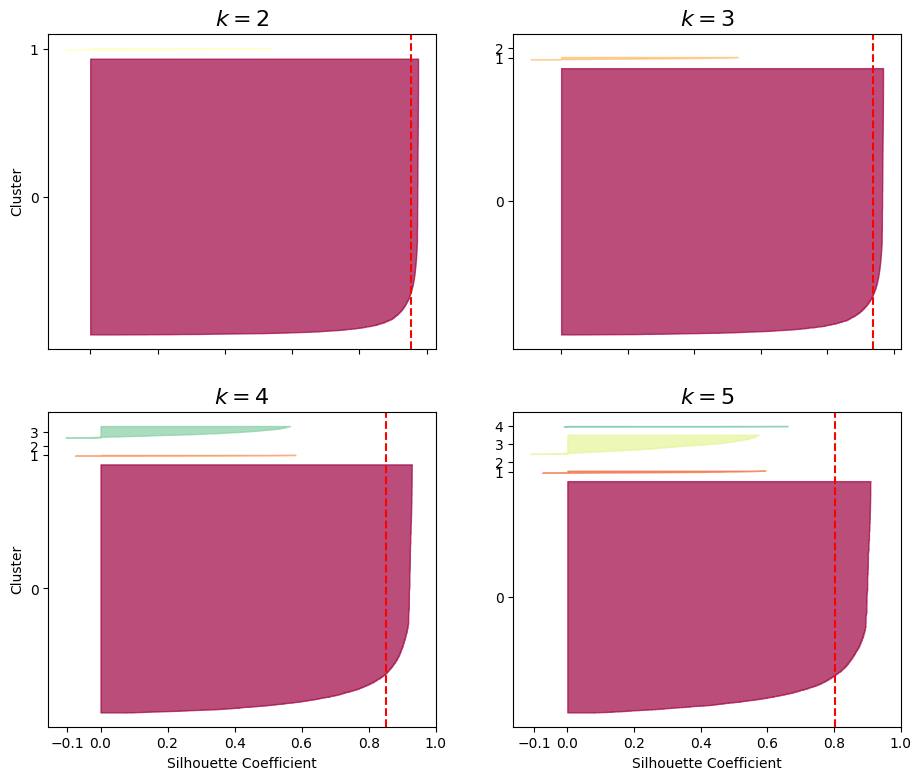

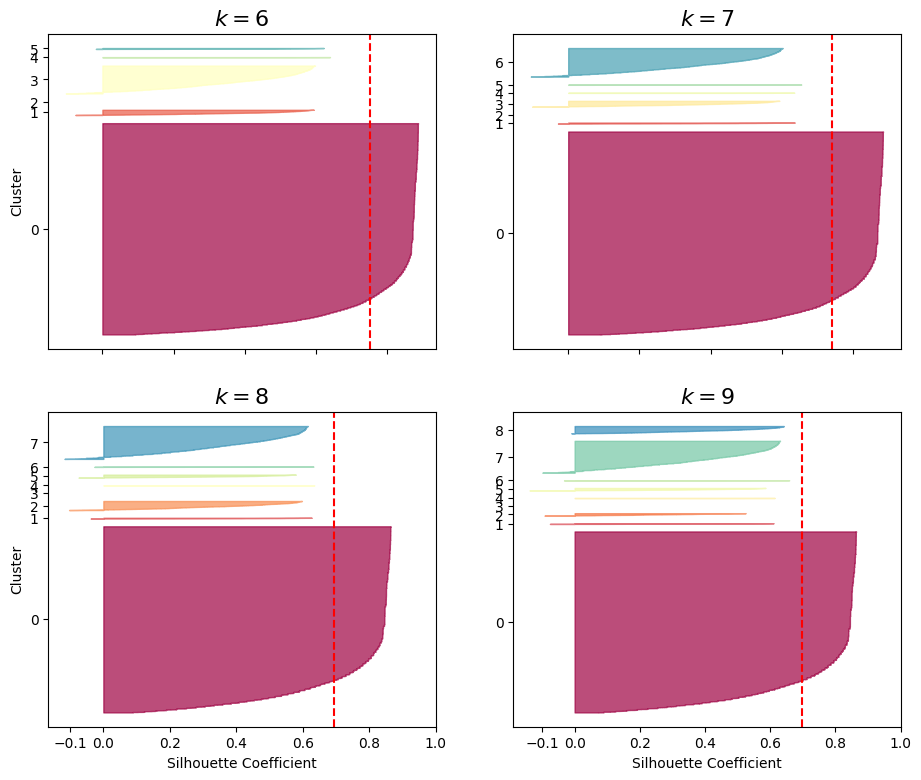

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

# Display silhouette diagrams for k=2, 3, 4, 5
plt.figure(figsize=(11, 9))
valid_ks_1 = [k for k in range(2, 6) if k <= len(kmeans_per_k) + 1] # Adjusted range check

for plot_idx, k in enumerate(valid_ks_1):
    plt.subplot(2, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 2].labels_
    silhouette_coefficients = silhouette_samples(data.values, y_pred)

    padding = len(data.values) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if plot_idx % 2 == 0:
        plt.ylabel("Cluster")

    if plot_idx >= 2:
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    # silhouette_scores list is indexed from k=2, so k=2 is index 0, k=3 is index 1, etc.
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

plt.figure(figsize=(11, 9))
valid_ks_2 = [k for k in range(6, 10) if k <= len(kmeans_per_k) + 1]

for plot_idx, k in enumerate(valid_ks_2):
    plt.subplot(2, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 2].labels_
    silhouette_coefficients = silhouette_samples(data.values, y_pred)

    padding = len(data.values) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if plot_idx % 2 == 0:
        plt.ylabel("Cluster")

    if plot_idx >= 2: # Check if it's the bottom row
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

### K-Means para aprendizaje semi-supervisado.

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATASETS/playdataset4.csv')

In [ ]:
from sklearn.cluster import KMeans

k = 5  # Reducimos el número de clústeres a un valor más adecuado para el dataset
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(data.values) # Usamos data.values en lugar de X_train

In [ ]:
print(X_digits_dist.shape)
print(X_digits_dist)

(16598, 5)
[[8.25603256e+01 7.38278135e+01 1.34869915e-06 8.03230702e+01
  5.72269365e+01]
 [4.05448303e+01 3.17817590e+01 4.26085860e+01 3.83038139e+01
  1.50142207e+01]
 [3.57530343e+01 2.69874858e+01 4.69200043e+01 3.35095902e+01
  1.03072686e+01]
 ...
 [2.57485921e-01 9.02729028e+00 8.28158548e+01 2.50092636e+00
  2.57975988e+01]
 [2.57485921e-01 9.02729028e+00 8.28158548e+01 2.50092636e+00
  2.57975988e+01]
 [2.57485921e-01 9.02729028e+00 8.28158548e+01 2.50092636e+00
  2.57975988e+01]]


In [ ]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = data.values[idxs] # Usamos data.values en lugar de X_train.values

In [ ]:
print(X_representative_digits.shape)
print(X_representative_digits)

(5, 2)
[[4.000e-02 2.600e-01]
 [1.580e+00 8.420e+00]
 [3.770e+00 8.274e+01]
 [2.600e-01 2.500e+00]
 [1.930e+00 2.476e+01]]


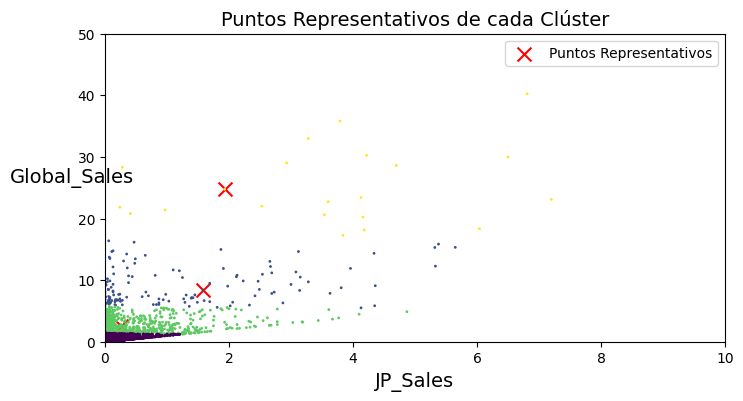

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Definición de la función plot_clusters
def plot_clusters(data, y=None, xlim=None, ylim=None):
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=y, s=1)
    plt.xlabel(data.columns[0], fontsize=14)
    plt.ylabel(data.columns[1], fontsize=14, rotation=0)
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

plt.figure(figsize=(8, 4)) # Ajustamos el tamaño de la figura si es necesario
# Usamos un gráfico de dispersión para visualizar los puntos representativos
plt.scatter(X_representative_digits[:, 0], X_representative_digits[:, 1], marker='x', s=100, color='red', label='Puntos Representativos')
# Opcional: Graficar también todos los puntos del dataset para contexto
plot_clusters(data, y=kmeans.labels_, xlim=(0, 10), ylim=(0, 50)) # Reutilizamos la función plot_clusters para los puntos originales con etiquetas
plt.legend()
plt.xlabel(data.columns[0], fontsize=14)
plt.ylabel(data.columns[1], fontsize=14, rotation=0)
plt.title("Puntos Representativos de cada Clúster", fontsize=14)
plt.show()

In [ ]:
y_representative_digits = y_train.values[idxs]

In [ ]:
from sklearn.linear_model import LogisticRegression


log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
# log_reg2.score(X_test, y_test) # Eliminamos la evaluación con X_test

CPU times: user 22.5 ms, sys: 998 µs, total: 23.5 ms
Wall time: 26.2 ms


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='ovr', random_state=42)

In [ ]:
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[:50], y_train[:50])
log_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 176 ms, sys: 18 µs, total: 176 ms
Wall time: 93.6 ms


0.566

In [ ]:
y_train_propagated = np.empty(len(data)) # Inicializamos con la longitud correcta de 'data'
for i in range(k):
  y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i] # Usamos el índice del clúster 'i'

In [ ]:
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(data.values, y_train_propagated) # Usamos data.values en lugar de X_train[:1000]
# log_reg3.score(X_test, y_test) # Eliminamos la evaluación con X_test

CPU times: user 128 ms, sys: 742 µs, total: 128 ms
Wall time: 106 ms


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='ovr', random_state=42)

### Aprendizaje Activo

In [ ]:
probas = log_reg3.predict_proba(data.values) # Usamos data.values en lugar de X_train
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.49054951, 0.49107029, 0.49290458, 0.49592924, 0.49592924,
       0.49592924, 0.49592924, 0.49592924, 0.49592924, 0.49592924])

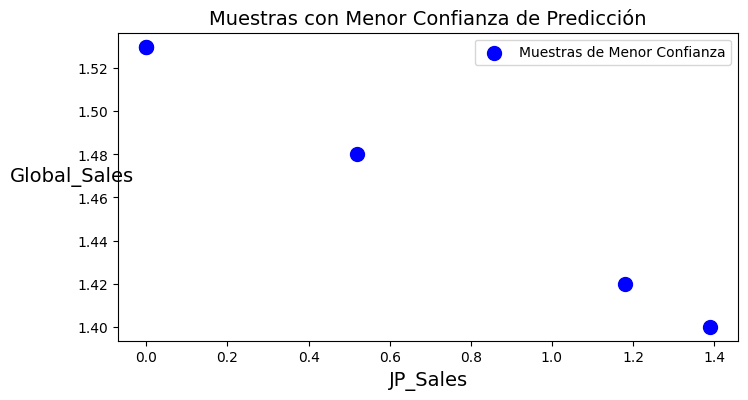

In [ ]:
X_lowest = data.values[sorted_ixs[:k]] # Seleccionamos de data.values
plt.figure(figsize=(8, 4))

plt.scatter(X_lowest[:, 0], X_lowest[:, 1], marker='o', s=100, color='blue', label='Muestras de Menor Confianza')

plt.xlabel(data.columns[0], fontsize=14)
plt.ylabel(data.columns[1], fontsize=14, rotation=0)
plt.title("Muestras con Menor Confianza de Predicción", fontsize=14)
plt.legend()
plt.show()

In [ ]:

y_lowest = y_train.values[sorted_ixs[:k]]
y_lowest

array([7, 1, 4, 2, 4])

In [ ]:
y_train2 = y_train_propagated.copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [ ]:
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(data.values, y_train2)


CPU times: user 216 ms, sys: 1.22 ms, total: 218 ms
Wall time: 113 ms


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='ovr', random_state=42)

Podemos repetir el proceso tantas veces como haga falta hasta llegar a las prestaciones requeridas.

## Otras técnicas de aprendizaje no supervisado

Otras técnicas muy usadas de aprendizaje no supervisado son

### DBSCAN

Este algoritmo define *clusters* como regiones continuas de alta densidad, agrupando progresivamente muestras cercanas entre ellas.

In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [ ]:
np.unique(dbscan.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6])

In [ ]:
dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)
np.unique(dbscan2.labels_)

array([0, 1])

In [ ]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

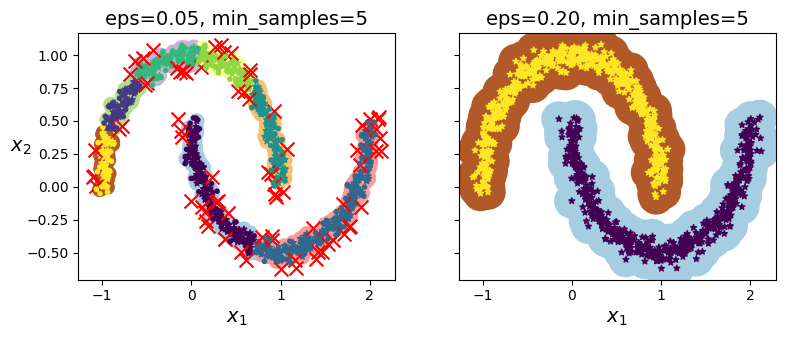

In [ ]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

plt.show()

Podemos considerar las muestras fuera de los grupos como anomalías, o bien usar un clasificador de vecinos cercanos para clasificar nuevas muestras.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan2.components_, dbscan2.labels_[dbscan2.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [ ]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

In [ ]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

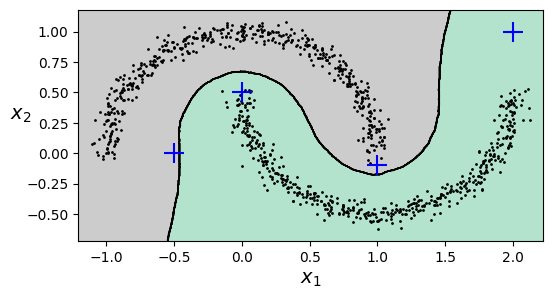

In [ ]:
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
plt.show()

### Gaussian Mixtures

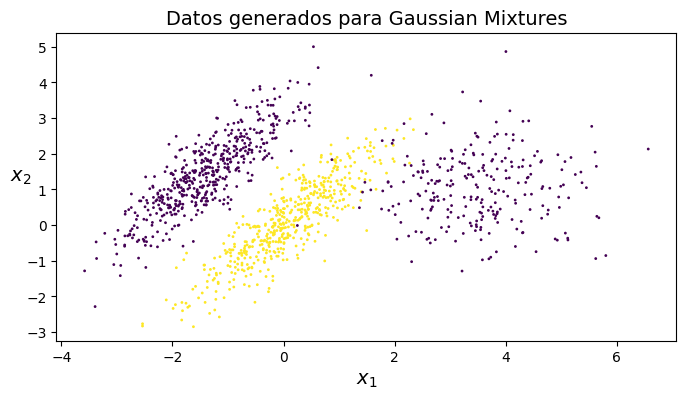

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Definición de la función plot_clusters (copiada de la celda tLCDbRD-7Aqs)
def plot_clusters(data, y=None, xlim=None, ylim=None):
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=y, s=1)
    plt.xlabel(data.columns[0], fontsize=14)
    plt.ylabel(data.columns[1], fontsize=14, rotation=0)
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]
# plot_clusters(X) # This function expects a pandas DataFrame, not a numpy array X
# The original notebook used plot_clusters with a pandas DataFrame earlier.
# For consistency with the notebook's example data generation for Gaussian Mixtures,
# it's better to plot using matplotlib directly on the numpy array X generated here.
plt.figure(figsize=(8, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=1) # Plotting directly using matplotlib
plt.xlabel("$x_1$", fontsize=14)
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.title("Datos generados para Gaussian Mixtures", fontsize=14)
plt.show()

In [ ]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10, random_state=42)

In [ ]:
from matplotlib.colors import LogNorm

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$", fontsize=14)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

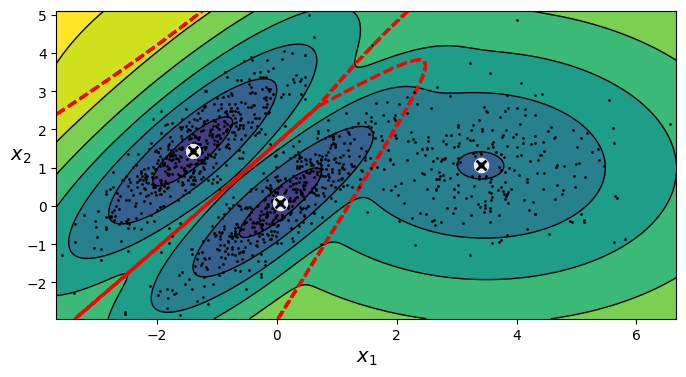

In [ ]:
plt.figure(figsize=(8, 4))
plot_gaussian_mixture(gm, X)
plt.show()

In [ ]:
gm.weights_

array([0.40005972, 0.20961444, 0.39032584])

In [ ]:
gm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

In [ ]:
gm.covariances_

array([[[ 0.63478217,  0.72970097],
        [ 0.72970097,  1.16094925]],

       [[ 1.14740131, -0.03271106],
        [-0.03271106,  0.95498333]],

       [[ 0.68825143,  0.79617956],
        [ 0.79617956,  1.21242183]]])

In [ ]:
gm.predict(X)

array([2, 2, 0, ..., 1, 1, 1])

In [ ]:
gm.predict_proba(X)

array([[6.76282339e-07, 2.31833274e-02, 9.76815996e-01],
       [6.74575575e-04, 1.64110061e-02, 9.82914418e-01],
       [9.99922764e-01, 1.99781831e-06, 7.52377580e-05],
       ...,
       [2.12540639e-26, 9.99999568e-01, 4.31902443e-07],
       [1.45002917e-41, 1.00000000e+00, 5.20915318e-16],
       [7.93266114e-41, 1.00000000e+00, 2.30971331e-15]])

Estos modelos son generativos, por lo que permiten crear nuevas muestras.

In [ ]:
X_new, y_new = gm.sample(6)
X_new

array([[-2.32491052,  1.04752548],
       [-1.16654983,  1.62795173],
       [ 1.84860618,  2.07374016],
       [ 3.98304484,  1.49869936],
       [ 3.8163406 ,  0.53038367],
       [ 0.38079484, -0.56239369]])

In [ ]:
y_new

array([0, 0, 1, 1, 1, 2])

Definiendo un valor límite podemos detectar anomalías en los datos.

In [ ]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 4)
anomalies = X[densities < density_threshold]

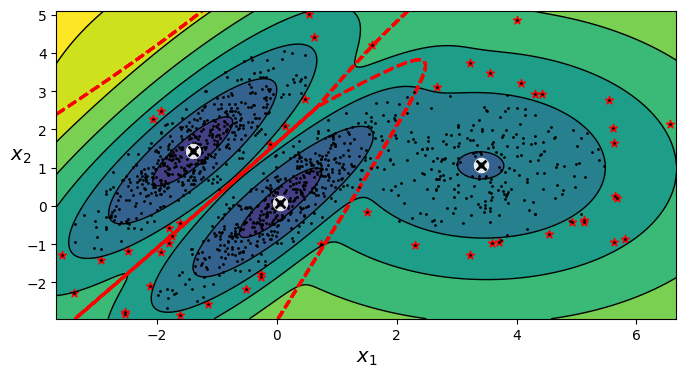

In [ ]:
plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='r', marker='*')
plt.ylim(top=5.1)

plt.show()

Una alternativa muy usada para seleccionar el número de grupos óptimos es el uso de *Bayesian Gaussian Mixtures*, ya que pueden asignar pesos cercanos a 0 a grupos innecesarios.

In [ ]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X)

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)

In [ ]:
np.round(bgm.weights_, 2)

array([0.4 , 0.21, 0.  , 0.4 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

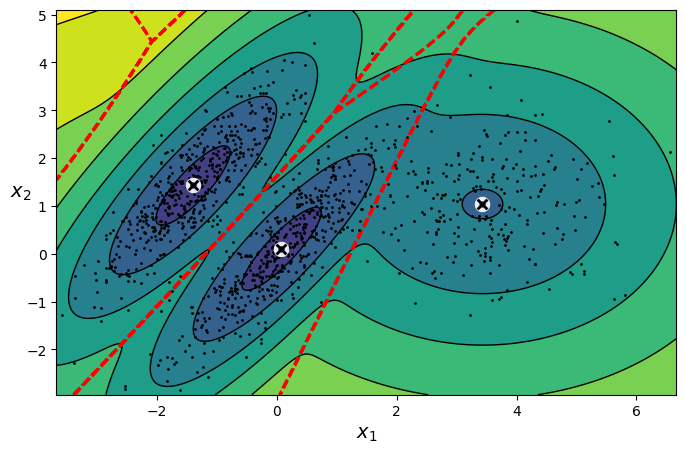

In [ ]:
plt.figure(figsize=(8, 5))
plot_gaussian_mixture(bgm, X)
plt.show()